# Aula 10


# Autoencoder Variacional - Parte 1


### Eduardo Lobo Lustosa Cabral

## 1. Objetivos

Nessa aula é apresentado o que é um autoencoder variacional (AEV), a intuição por trás do seu funcionamento e suas aplicações como uma ferramenta geradora para qualquer tipo de dado.

Mais especificamente vamos ver:

- O que é um autoencoder variacional.

- Como funciona um AEV.

- Definir a função de custo usada para treinar um AEV.

- Treinar um AEV com camadas densas.

### Importação das bilbiotecas necessárias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)

2.19.0


## 2. Introdução

Em contraste com os usos mais padrões de redes neurais como ajuste de funções ou classificadores e mesmo os autoencoders comuns, os autoencoders Variacionais (AEVs) são modelos generativos poderosos. Atualmente eles são aplicados em diversas tarefas, tais como, gerar rostos humanos e produção de música puramente sintética.

Ao usar modelos generativos pode-se desejar simplesmente gerar uma nova saída aleatória, semelhante aos dados de treinamento. Porém, com frequência, é desejado alterar ou explorar variações nos dados existentes, e não apenas de forma aleatória, mas em uma direção específica desejada $\to$ os AEVs funcionam muito bem para esse tipo de tarefa.


### 2.1 Comparação entre AE e AEV

Os autoencoders padrão aprendem a gerar representações compactas e reconstruir bem suas entradas, mas com exceção de algumas aplicações, tal como, eliminação de ruído eles são bastante limitados.

O problema fundamental com os autoencoders padrão, para geração de novos dados, é que o espaço latente para o qual eles convertem suas entradas pode não ser contínuo ou não permitir uma interpolação fácil.

Por exemplo, treinar um autoencoder no conjunto de dados MNIST e visualizar as codificações de um espaço latente 2D revela a formação de clusters distintos. Isso faz sentido, pois codificações distintas para cada tipo de imagem tornam muito mais fácil para o decodificador decodificá-los. Isso é bom se for desejado apenas replicar as mesmas imagens.

Mas de um modelo generativo se deseja mais do que replicar os mesmos dados de entrada. Nesse caso é desejado amostrar aleatoriamente o espaço latente, ou gerar variações nos dados de entrada a partir de um espaço latente contínuo.

Se o espaço latente tiver descontinuidades (por exemplo, lacunas entre os agrupamentos) e se for desejado amostrar/gerar uma variação a partir desse espaço, o decodificador pode simplesmente gerar uma saída irreal, porque ele não tem ideia de como lidar com uma região "vazia" do espaço latente. Durante o treinamento, ele nunca viu vetores codificados vindos daquela região do espaço latente.

## 3. Autoencoders variacionais

Da mesma forma que um autoencoder padrão, um autoencoder variacional cria um espaço latente para representar os dados de entrada, que consiste de uma versão com dimensão reduzida que pode ser utilizada para gerar dados que se parecem com os originais.

Autoencoders variacionais têm uma propriedade fundamentalmente única que os distingue dos autoencoders padrão, e é essa propriedade que os torna tão úteis para modelagem generativa: seus espaços latentes são contínuos, permitindo amostragem fácil e interpolação aleatória.

Um AEV é uma abordagem probabilística do autoencoder padrão. Ao contrário de um autoencoder tradicional, que mapeia a entrada em um vetor latente determinístico, um AEV mapeia os dados de entrada nos parâmetros de uma distribuição de probabilidade, tal como por exemplo, a média e a variância de uma distribuição Gaussiana. Dessa forma, a diferença básica entre um autoencoder padrão e um autoencoder variacional é que o código gerado pelo codificador é substituído por códigos que representam a distribuição de probabilidade das entradas. Essa abordagem produz um espaço latente contínuo e estruturado, útil para a geração de novos dados.

Na medida em que um AEV gera uma representação do espaço latente probabilística, as saídas reconstruídas são associadas com probalilidades de forma que são diferentes das entradas, mas similares a estas.

Na Figura 1 é mostrado um esquema de um autoencoder padrão e de um autoencoder variacional.

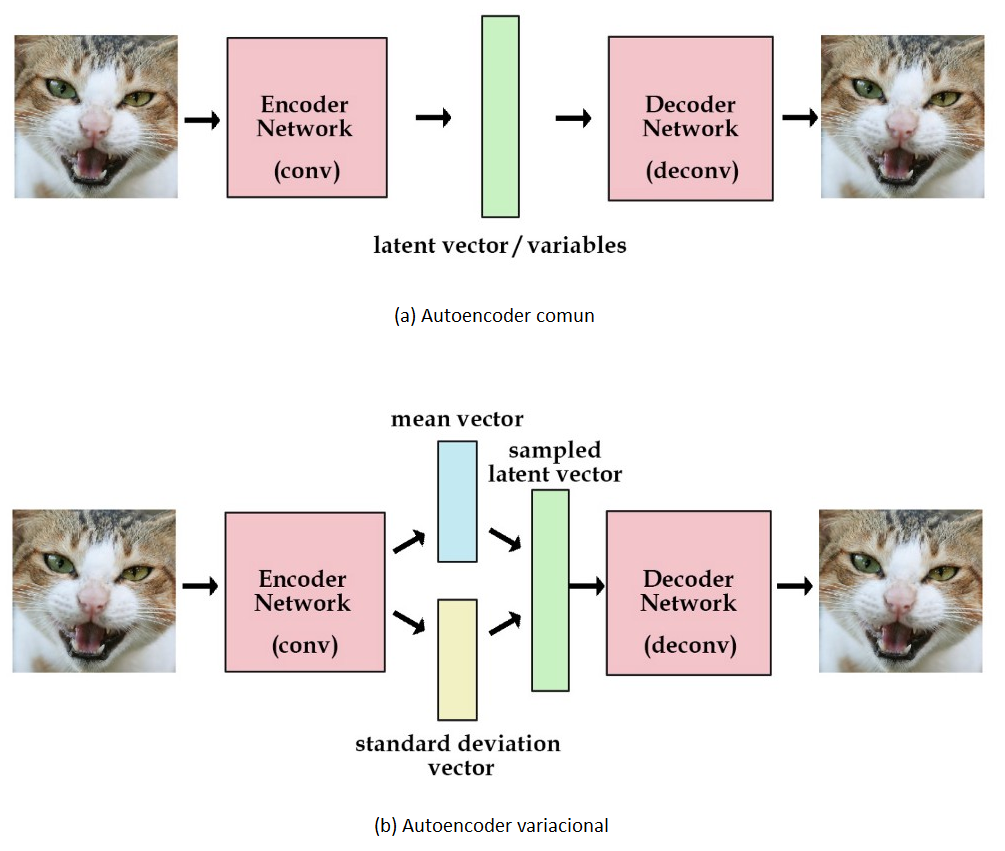
<center>Figura 1 - (a) Esquema simplificado de um autoencoder padrão;(b) Esquema de um autoencoder variacional (Kevin Frans blog (2018). Variational Autoencoders Explained. Disponível em: http://kvfrans.com/variational-autoencoders-explained/.</center>

### 3.1 Princípio de funcionamento de um AEV


Em geral nos AEVs assume-se que a distribuição de probabilidades dos dados de entrada é Gaussiana. Assim, por exemplo, para um conjunto de vetores a distribuição de probabilidade é repesentada por:

- Um vetor de médias, onde cada elemento desse vetor representa a média dos respectivos elementos dos vetores.
- Um vetor de desvio padrão, onde cada elemento desse vetor representa o desvio padrão de cada elemento dos vetores.

A média e o desvio padrão gerados pelo codificador formam parâmetros de um vetor de variáveis aleatórias com uma determinada dimensão. O primeiro elemento do vetor de média  $\mu$  e o primeiro elemento do vetor de desvio padrão $\sigma$ representam a média e o desvio padrão da primeria variável da representação latente, a partir da qual é feita a amostragem do primeiro elemento do código. O código amostrado dessa distruibuição é passado para o decodificador gerar a saída.

Para exemplificar esse processo, vamos considerar a seguinte distruibuição Gaussiana de probabilidade:

- Média: $\mu = [0.1;2.0;0.2;0.5]$


- Desvio padrão: $\sigma = [0.2;0.5;0.8;1.3]$


- Distribuição de probabiliade:  $[𝑁_1(0.1;0.2),𝑁_2(2.0;0.5),𝑁_3(0.2;0.8),𝑁_4(0.5;1.3)]$


- Código amostrado:  $z = [0.28;1.65;0.92;1.78]$


Pode-se ver, que os vetores de média e desvio padrão definem uma distribuição de probabilidade onde um código que representa um dado pode ser amostrado.

Essa geração estocástica do código significa que, mesmo para uma determinada entrada, embora a média e o desvio padrão permaneçam os mesmos, a codificação real vai variar um pouco em cada passagem de um mesmo dado simplesmente devido à amostragem.

Na Figura 2 é mostrada a diferença entre a obtenção de um elemento do código em um AE padrão e em um AEV.

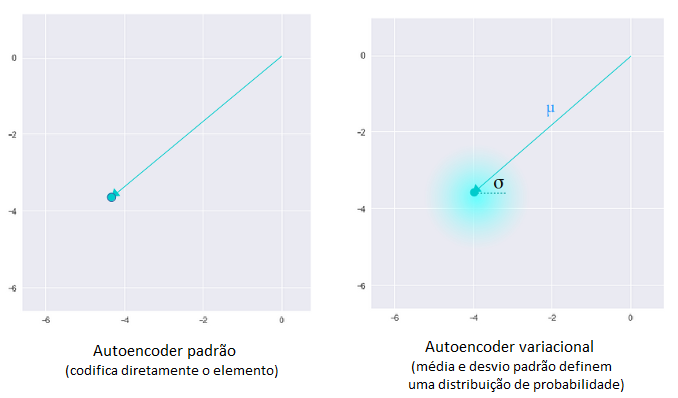
<center>Figura 2 - Diferença da geração de um código realizado em um AE e em um AEV (https://towardsdatascience.com/intuitively-understanding-variational-autoencoders-1bfe67eb5daf).</center>

Intuitivamente, o vetor de médias controla onde a codificação de uma entrada deve ser centrada, enquanto o desvio padrão controla a “área” onde amostrar o elemento, ou seja, quanto em torno da média a codificação pode variar.

Como as codificações são geradas aleatoriamente de qualquer lugar dentro do "círculo", ou seja, segundo a distribuição, o decodificador aprende que não é apenas um único ponto no espaço latente que se refere a uma amostra dessa classe, mas todos os pontos próximos também se referem à mesma classe. Isso permite que o decodificador decodifique não apenas codificações únicas e específicas do espaço latente (que formaria um espaço latente descontínuo), mas também aquelas que variam ligeiramente, pois o decodificador é exposto a uma gama de variações da codificação da mesma entrada durante o treinamento.

A amostragem faz com que o autoencoder fique exposto a um certo grau de variação local ao variar a codificação de uma amostra. Isso resulta em espaços latentes suaves em uma escala local.

### 3.2 Amostragem de uma distribuição gaussiana

Tendo o vetor de média $\mu$ e o vetor de desvio padrão $\sigma$ de uma distribuição Gaussina, pode-se obter facilmente um vetor de amostra dessa distribuição.

Seja $\alpha$ um vetor de variáveis aleatórias, onde cada elemento consiste de uma amostra de uma distribuição Gaussiana de média 0 e desvio padrão 1. Então,

$$z = \mu + \alpha \sigma$$

onde $z$ é um vetor de amostra da distribuição de média $\mu$ e desvio padrão $\sigma$. Portanto, para amostrar uma distribuição Guassina basta aleatóriamente escolher uma dispersão em torno da sua média que seja função do desvio padrão.


### 3.3 Divergência de Kullbak-Leiber

Idealmente, é desejado sobrepor amostras que também não são muito semelhantes com a finalidade de interpolar entre as diferentes classes. No entanto, uma vez que não há limites para os valores que os vetores de média e desvio padrão podem assumir, o codificador pode aprender a gerar vetores de média muito diferentes para classes diferentes, agrupando-os separadamente e, assim, minimizar o desvio padrão para garantir que as codificações em si não variem muito para a mesma amostra (ou seja, menos incerteza para o decodificador). Isso permite que o decodificador reconstrua com mais eficiência os dados de treinamento.

Na Figura 3 é mostrado dois exemplos de códigos que se pode obter no treinamento de um AEV.

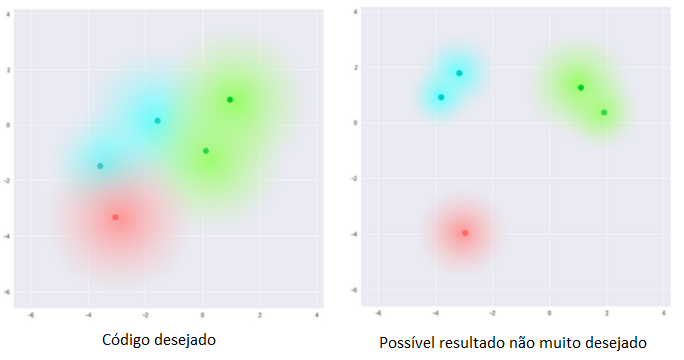
<center>Figura 3 - Exemplos de diferentes códigos gerados por um AEV (https://towardsdatascience.com/intuitively-understanding-variational-autoencoders-1bfe67eb5daf).</center>

O que desejamos idealmente são codificações que estejam próximas umas das outras, embora distintas, de forma a permitir uma interpolação suave e possibilitando a construção de novos dados.

Para forçar que as codificações fiquem próximas umas das outras e que seja possível realizar uma amostragem contínua, é adicionada à função de custo normal um termo de regularização que consiste na divergência de Kullback-Leibler (https://www.countbayesie.com/blog/2017/5/9/kullback-leibler-divergence-explained).

A divergência Kullback-Leiber entre duas distribuições de probabilidade $p(x)$ e $q(x)$ de um vetor $x$ é definida por:

$$D_{KL}(p,q)=E \big[ log\big(p(x)\big) - log\big(q(x)\big) \big]$$

onde $E$ é a expectativa (valor médio) da diferença entre o logaritmo da distribuição de probabilidade real dos dados $p(x)$ e o logaritmo da distribuição aproximada $q(x)$.

A divergência KL entre duas distribuições de probabilidade simplesmente mede o quanto elas são diferentes.

Aplicando a divergência KL para duas distribuições normais, assumindo que $q(x)$ possui média zero e desvio padrão um e $p(x)$ possui média $\mu$ e desvio padrão $\sigma$ a divergência KL entre as duas distribuições é dada por:

$$D_{KL}(p,q) = \frac{1}{2} \big [\sigma^2 + \mu^2 - log(\sigma^2) - 1 \big ]$$

Aplicando a divergência KL dada pela equação anterior para um vetor $x$ de $n$ variáveis, onde cada variável possui uma distribuição normal definida por $N_j(\mu_j, \sigma_j)$ para $j=1,..,n$, resulta na seguinte expressão:

$$D_{KL} = \frac{1}{2} \sum_{j=1}^n \big [\sigma_j^2 + \mu_j^2 - log(\sigma_j^2) - 1 \big]$$

Observa-se que nesse caso a divergência KL é minimizada quando $\mu_j = 0$ e $\sigma_j = 1$, para $j=1,..,n$.

### 3.4 Motivação estatística para uso da divergência KL

Suponha que existe uma variável $z$ que não conhecemos, mas que a partir de alguma transformação gera a observação $x$, como mostrado na Figura 4.

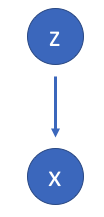
<center>Figura 4 - Transformação de $z$ obtendo $x$.</center>

Portanto, somente podemos observar a variável $x$, mas gostaríamos de inferir as características de $z$ tendo a variável $x$. Em outras palavras queremos calcular a distribuição de probabilidade de $z$ tendo $x$, ou seja, obter $p(z|x)$, que é defina pela seguinte exepressão:

$$p(z|x) = \frac {p(x|z) p(z)} {p(x)}$$

onde $p(z|x)$ é a distribuição de probabilidade condicional de $z$ dado $x$, $p(x|z)$ é a distribuição de probabilidade condicional de $x$ dado $z$, $p(z)$ é a distribuição de probabilidade de $z$ e $p(x)$ é a distribuição de probabilidade de $x$.

Infelizmente, calcular essa expressão é impossível pois não conhecemos $z$. Contudo, podemos pelo menos inferir o valor da distribuição $p(z|x)$ aproximando-a por alguma outra distribuição $q(z|x)$, tal como uma distribuição Gaussina. Dessa forma, se pudermos calcular $q(z|x)$, de tal forma que seja aproximadamente igual a $p(z|x)$, então, podemos usar $q(z|x)$ para obter $z$ ou obter uma reconstrução de $x$ dado $p(x|z)$.

Como visto, a divergência KL é uma medida da diferença entre duas distribuições de probabilidade. Dessa forma, se quisermos garantir que $p(z|x)$ seja similar a $q(z|x)$, podemos minimizar a divergência KL entre essas duas distribuições, ou seja:

$$ min \big[{D_{KL} (q(z|x), p(z|x))} \big]$$

Aplicando aos AEVs, podemos usar a distribuição $q(z|x)$ para obter a representação latente dos dados de entrada, que por sua vez é usada para gerar uma observação dos mesmos. Assim, o codificador é treinado para mapear $x$ para $z$ usando a distribuição $q(z|x)$ e o decodificar é treinado a mapear $z$ de volta a $x$ usando a distribuição $p(x|z)$.

Na figura 5 é mostrado um esquema de AEV onde são identificadas as distribuições de probabilidades envolvidas.


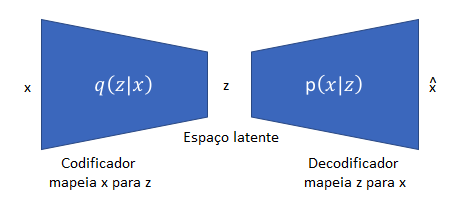
<center>Figura 5 - Distribuições de probabilidades presentes em um AEV.</center>

Em um AEV a distribuição aproximada do espaço latente é adotada como sendo a distribuição gaussiana padrão (média igual a 0 e desvio padrão igual a 1). Portanto, minimizar a divergência KL em um AEV significa fazer com que os parâmetros de distribuição de probabilidade (média e desvio padrão) do espaço latente fiquem próximos da distribução gaussiana normal

Para os AEVs, o custo KL é equivalente à soma de todas as divergências KL entre as distribuições de probabilidade dos elementos $z_j$ do vetor $z$ (espaço latente), ou seja $N_j(\mu_j, \sigma_j)$, e a distribuição Gaussiana padrão (média zero e desvio padrão 1). Dessa forma, estamos forçando com que a distribuição de probabilidade de cada elemento do espaço latente se aproxime de uma distribuição Gaussiana com média 0 e desvio padrão 1.

Intuitivamente, o custo KL incentiva o codificador a distribuir todas as codificações (para todos os tipos de entradas) uniformemente em torno do centro do espaço latente. Se tentar “trapacear” agrupando-as em regiões específicas, longe da origem, será penalizado.

### 3.5 Função de custo usada para treinar uma AEV

Para minimizar o erro entre $x$ e a sua reconstrução $\hat{x}$, a função de erro do AEV para cada exemplo de treinamento é composta por:

1. um termo que minimiza o erro de reconstrução de $\hat{x}$ em relação a $x$;

2. um termo que "encoraja" a distribuição aprendida $p(z|x)$ a ser similar à distribuição $q(x|z)$, que assumimos ser uma distribuição Gaussiana com média 0 e desvio padrão 1 para cada elemento da representação latente.


Dessa forma, temos a seguinte função de erro para cada exemplo de treinamento:

$$ E(x^{(i)}, \hat{x}^{(i)}) = E_{padrão}(x^{(i)}, \hat{x}^{(i)}) + \sum_{j=1}^{n} D_{KL,j} \big(q_j(z|x), p_j(z|x) \big)$$

onde $E(x^{(i)}, \hat{x}^{(i)})$ é o erro entre a i-ésima entrada $x^{(i)}$ e a sua reconstrução na saída do AEV  $\hat{x}^{(i)}$, $E_{padrão}(x^{(i)}, \hat{x}^{(i)})$ é o erro de reconstrução e o terceiro termo é a divergência KL para todos os elementos da representação latente.

Nota-se que se usarmos somente o termo de regularização KL na função de custo para treinar um AEV, resulta em um espaço latente onde as codificações se distruibuem aleatoriamente perto do centro do espaço latente, sem considerar a "distância" entre entradas muito diferentes e a "proximidade" entre entradas similares. Com isso, se torna impossível decodificar qualquer coisa significativa deste espaço, simplesmente porque realmente não há nenhum significado.

Por outro lado se usarmos somente o erro entre a entrada $x$ e a sua reconstrução $\hat{x}$ o espaço latente resultante terá lacunas e se torna inútil para interpolar diferentes entradas e obter dados novos diferentes dos usados no treinamento.

A divergência KL é adicionada à uma função de custo padrão, que garante que a saída reconstruída seja similar à entrada, na forma de um termo de regularização para garantir que a distribuição de probabilidade do espaço latente seja a mais próxima de uma distribuição Gaussiana padrão.  

A função de custo para treinar um AEV é a média da função de erro para todos os exemplos de treinamento, assim temos:

$$J = \frac {1}{m} \big[ \sum_{i=1}^{m} E_{padrão}(x^{(i)}, \hat{x}^{(i)}) + \beta \sum_{i=1}^{m} \sum_j^n D_{KL,j}^{(i)} \big(q_j(z|x)^{(i)}, p(z)^{(i)} \big) \big]$$


onde $J$ é a função de custo usada para treinar o AEV, que é função de todos os parâmetros do AEV, $m$ é o número de exemplos de treinamento e $\beta$ é o fator de regularização.

O fator de regularização, $\beta$, é usado para ajustar a distribuição do espaço latente. Se usarmos um fator de regularização baixo, as desvantagens de um autoencoder padrão começam a aparecer. No entanto, se usarmos um fator de regularização muito alto, a qualidade das imagens reconstruídas será ruim. Portanto, o fator de regularização é um hiperparâmetro que precisa ser ajustado.

A função de erro padrão $E_{padrão}$ pode ser, por exemplo, a entropia binária cruzada, quando as saídas estão no intervalo entre 0 e 1, ou o erro quadrático quando as saídas possuem números fora do intervalo [0, 1].

Otimizar esse dois termos da função de custo, resulta na geração de um espaço latente que mantém a proximidade de codificações similares, o distanciamento de codificações diferentes e ainda é densamente compactado perto da origem do espaço latente.

Intuitivamente, este é o equilíbrio alcançado pela natureza da formação de agrupamentos da função de custo padrão e a natureza de compactação do custo KL.

Essa é a solução perfeita desejada, pois isso significa que ao gerar aleatoriamente um código com a mesma distribuição de uma entrada, o decodificador irá decodificá-lo com sucesso. Por outro lado, se for criado um código interpolando duas entradas diferentes, como não há lacunas entre os agrupamentos o decodificador também é capaz de entender.

Na Figura 6 é mostrado um exemplo de um espaço latente que representa figuras de formas geométricas criado sem o termo de regularização KL e de um espaço latente criado com o termo de regularização KL.

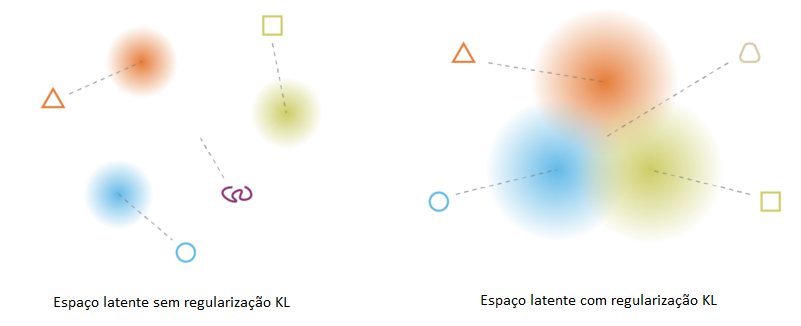
<center>Figura 6 - Exemplos de espaços latentes criados sem termo de regularização KL e com termo de regularização (https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73).</center>

No espaço latente criado com regularização KL é possível criar códigos interpolando entre códigos de diferentes formas para criar formas intermediárias entre as usadas no treinamento do AVE. Isso é graficamente mostrado na Figura 7.


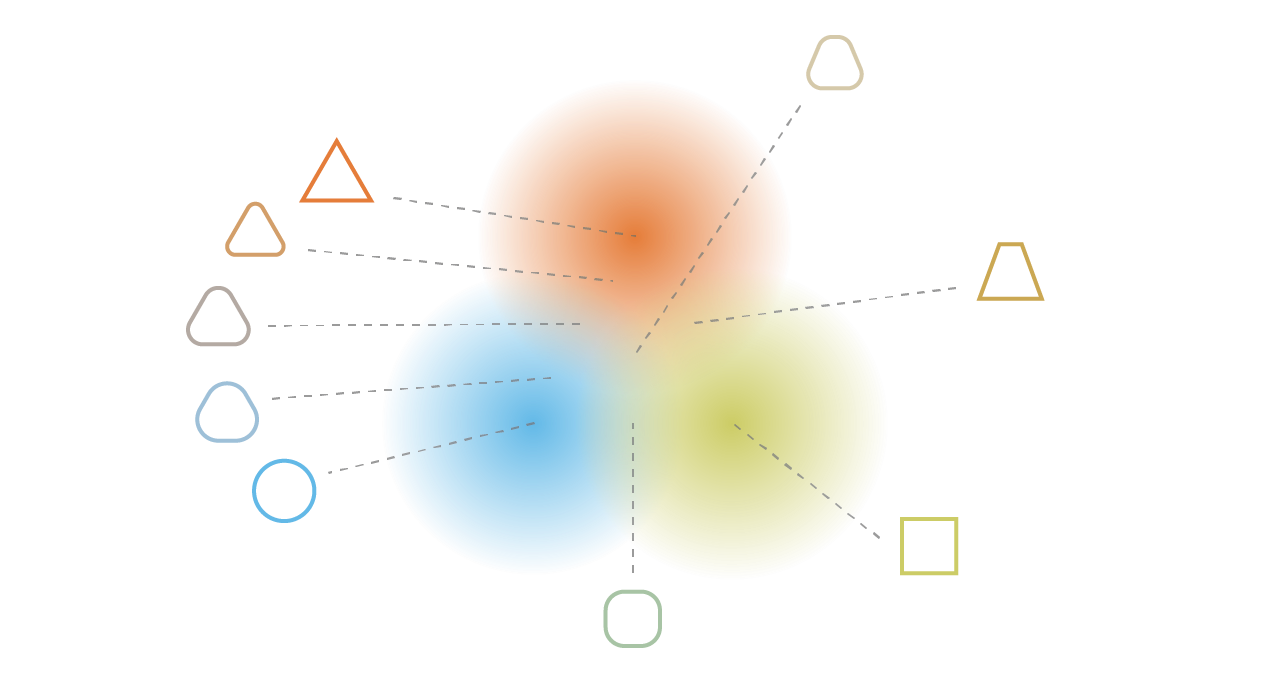
<center>Figura 7 - Interpolção de códigos do espaço latente para criar novas formas geométricas (https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73).</center>

### 3.6 Interpolação de representações latentes

A obtenção de um código que representa por exemplo a mistura de dois dados diferentes, com o objetivo do decodificador produzir uma saída que seja a mistura dos dois dados, é feita pela interpolação de vetores.

Por exemplo, se for desejado gerar um novo dado que seja a mistura com pesos iguais de dois dados, basta calcular a diferença entre os seus vetores de média (representação latente) e adicionar metade da diferença ao original e, em seguida, decodificar o resultado. Na Figura 8 é mostrado um exemplo gráfico dessa operação de calcular um novo código pela interpolação de outros dois.

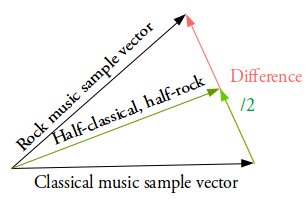
<center>Figura 8 - Cálculo da representação latente da mistura de dois dados (https://towardsdatascience.com/intuitively-understanding-variational-autoencoders-1bfe67eb5daf).</center>

Outra possibilidade para gerar novos dados é adicionar características específicas em dados, como por exemplo,
colocar óculos em um rosto. Para isso deve-se ter duas imagens de um mesmo rosto, uma com óculos e outra sem. Calcular as representações latentes dessas duas imagens e depois calcular a diferença entre elas. Essa diferença representa a cofificação latente do éculos. Assim, basta adicionar essa diferença (codificação do óculos) à representação latente de qualquer outra imagem de rosto e decodificar, o resultado será o rosto com óculos. Na Figura 9 é mostrado um exemplo gráfico de como calcular o código de um "óculos".

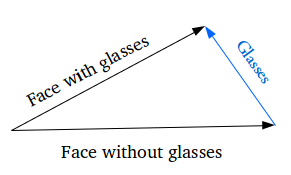
<center>Figura 9- Cálculo do código de uma característica diferente entre representações latentes de dados similares (https://towardsdatascience.com/intuitively-understanding-variational-autoencoders-1bfe67eb5daf).</center>

### 3.7 Arquitetura de um AEV

Na Figura 10 é apresentado um esquema da arquitetura de um AEV. Como visto, a representação latente gerada por um AEV é composta por dois elementos, a média e o desvio padrão dos dados de entrada. Ressalta-se, que esses elementos são de fato aprendidos durante o treinamento do AEV.

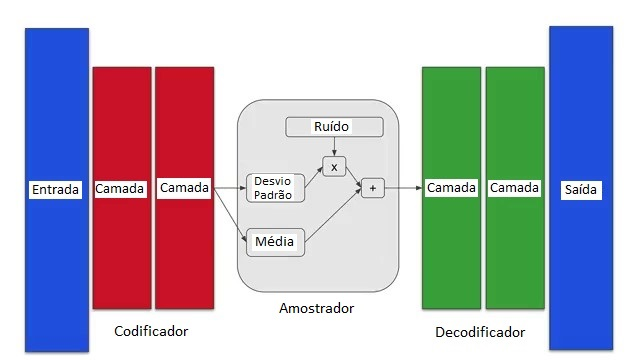
<center>Figura 10 - Arquitetura simplificada de um AEV.</center>

Como visto, no amostrador, para obter um código a ser decodificado pelo decodificador, o desvio padrão das entradas é multiplicado, elemento por elemento, por um ruído gaussiano com média zero e desvio padrão um. O resultado dessa operação é adicionado à média dos dados para gerar o código amostrado. Esse código é então usado pelo decodificador para criar uma saída diferente da entrada.

A dimensão dos tensores de média e desvio padrão do código é função do problema e da configuração das camadas do AEV. Esses tensores são aprendidos durante o treinamento para que o AEV reproduza na sua saída os dados de entrada. O decodificador, mesmo durante o treinamento, utiliza representações latentes amostradas da distribuição de probabilidade dos dados.

Um AEV pode ser construído com qualquer tipo de camada (densa, convolucional ou recorrente), dependendo do tipo de dado que se deseja utilizar, e pode ter quantas camadas forem necessárias para o problema em questão. Também é possível usar modelos pré-treinados no codificador e realizar transferência de aprendizado para ajustá-lo aos novos dados.

## 4. Autoencoder variacional com camadas densas

Um AEV com camadas densas é utilizado geralmente quando os dados de entrada não possuem muitos elementos e quando não existem dependência temporal entre eles.

Para exemplificar vamos implementar um AEV para reconstruir os dígitos do conjunto MNIST.

Como as imagens do conjunto de dígitos MNIST são pequenas e em tons de cinza, vamos processar as imagens de dígitos usando RNAs com camadas densas.

### 4.1 Carregar e processar dados

A célula abaixo carrega o conjunto de dados de dígitos MNIST da coleção do Keras.

Para treinar um AEV não faz muito sentido usar dados de validação porque o desejado é gerar um espaço latente com o maior número possível de dados. Assim, vamos usar um único conjunto de dados composto pela união dos dados de treinamento e teste.

In [ ]:
# Carrega dados
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Junta dados de treinamento e de teste
digits = np.concatenate([x_train, x_test], axis=0)
labels = np.concatenate([y_train, y_test], axis=0)

print('Dimensão das imagens de entrada =', digits.shape)
print('Dimensão dos rótulos de saída =', labels.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensão das imagens de entrada = (70000, 28, 28)
Dimensão dos rótulos de saída = (70000,)


Vamos redimensionar as imagens para transformá-las em vetores e normalizá-las transformando os seus pixels em valores reais no intervalo entre 0 e 1.

In [ ]:
# Número de pixels nas imagens
nx = 28*28

# Normalização das imagens
x_train_flat = np.reshape(digits, (70000, nx))/255.

print('Dimensão dos dados de entrada de treinamento =', x_train_flat.shape)

Dimensão dos dados de entrada de treinamento = (70000, 784)


#### Gráficos de alguns exemplos

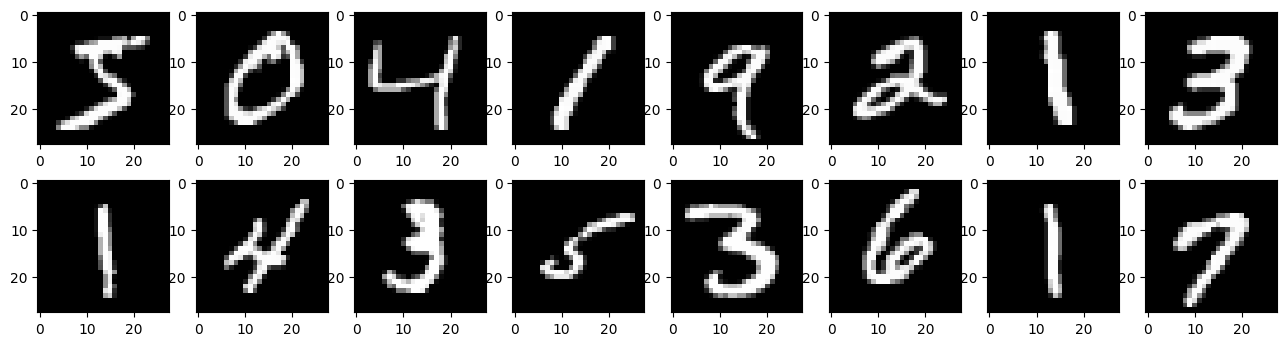

In [ ]:
fig, axs = plt.subplots(2, 8, figsize=(16, 4))
index = 0
for i in range(2):
    for j in range(8):
        axs[i,j].imshow(digits[index], cmap='gray')
        index += 1
plt.show()

### 4.2 Configuração do amostrador

O amostrador recebe como entradas o vetor de médias $\mu^{(i)}$ e o vetor de desvios padrão $\sigma^{(i)}$ do i-ésimo exemplo de treinamento, e a sua saída é uma representação latente amostrada da distribuição Gaussiana representada por esses vetores.

Para configurar o amostrador, a forma mais fácil é criar uma camada customizada. Lembre que a equação que o amostrador implementa para o i-ésimo exemplo é a seguinte:

$$z^{(i)} = \mu^{(i)} + \alpha \sigma^{(i)}$$

onde $z^{(i)}$ é o vetor amostrado da distribuição Gaussiana com média $\mu^{(i)}$ e desvio padrão $\sigma^{(i)}$ do i-ésimo exemplo e $\alpha$ é um vetor de números aleatório obtido de uma distribuição Gaussiana de média 0 e desvio padrão 1.

Foi verificado que o treinamento de um AEV é mais estável quando se usa o logarítmo do vetor da variância da distribuição Gaussiana das entradas. Assim, o codificador no lugar de calcular o vetor de desvio padrão das entradas calcula o vetor do logaritmo da variância das entradas, ou seja, $ln \big[ (\sigma^{(i)})^2 \big]$.

Assim, o amostrador deve calcular a exponencial da raiz quadrada desse vetor, elemento por elemento, para obter o desvio padrão das entradas antes de amostrar um código.

In [ ]:
# Importa classe de camadas e Keras backend
import tensorflow.keras.backend as K
from tensorflow.keras import layers

# Classe de camada do amsotrador
class Sampling(layers.Layer):
    # Método para inicializar classe
    def __init__(self):
        # Iniciliza classe
        super(Sampling, self).__init__()

    # Método para realizar cálculos na camada do amsotrador
    def call(self, inputs):
        """Dados de entrada:
        Vetor de médias: z_mean;
        Logaritmo do vetor de variâncias: z_log_var"""

        # Separa média e desvio padrão da entrada na forma de lista
        z_mean, z_log_var = inputs

        # Recupera dimensões dos tensores de média e desvio padrão
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        # Gera número aleatório com distribuição Gaussiana de média 0 e desvio padrão 1
        alfa = K.random_normal(shape=(batch, dim))

        # Retorna vetor de código amostrado
        return z_mean + tf.keras.ops.exp(0.5 * z_log_var) * alfa

- Observe que essa camada customizada não precisa do método `build()` pois não possui nenhum parâmetro.

### 4.3 Configuração do codificador

No codificador vamos usar duas camadas densas seguidas de uma camada de normalização de batelada e depois duas camadas densas em paralelo para calcular as médias e o logaritmo das variância das entradas.

As funções de ativação das duas primeiras camadas densas é a LeakyReLu.

Como a saída do codificador consiste de dois termos (média e desvio padrão), temos que usar a classe funcional para configurar o codificador.

In [ ]:
# Importa classes de modelos funcionals
from tensorflow.keras.models import Model

# Define número de unidades das camadas e do espaço latente
hidden1 = 512
hidden2 = 256
hidden3 = 128
hidden4 = 64
latent_dim = 2 # 12

# Define camada de entrada para receber as imagens já redimensionadas
encoder_inputs = layers.Input(shape=(nx,))

# Inclui camadas densas e de normalização de batelada
x = layers.Dense(hidden1, activation=layers.LeakyReLU())(encoder_inputs)
x = layers.Dense(hidden2, activation=layers.LeakyReLU())(x)
x = layers.Dense(hidden3, activation=layers.LeakyReLU())(x)
x = layers.Dense(hidden4, activation=layers.LeakyReLU())(x)
x = layers.LayerNormalization()(x)

# Inclui camadas para calcular media e log da variância
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Inclui camada de sampling
z = Sampling()([z_mean, z_log_var])

# Instância codificador
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Sumário do codificador
print('Codificadorr:')
print(encoder.summary())

Codificadorr:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    401,920 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64)        │        128 │ dense_3[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 574,788 (2.19 MB)

 Trainable params: 574,788 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

None


- Observe que  as camadas de saída do codificador que calculam o vetor de médias e o vetor do logaritmo das variâncias das entradas possuem função de ativação linear para não impor restrição à representação dos dados no espaço latente.

- Foi colocada uma camada de normalização de batelada após as camadas densas na tenatativa de normalizar as ativações antes das camadas de cálculo da média e desvio padrão.

Observe que o espaço latente é um plano, ou seja, as representações latentes tem somente 2 elementos. Assim, as imagens com 784 pixels são compactadas em vetores de 2 elementos, isso representa uma compactação muito grande.

Obviamente que com somente 2 elementos, a partir das representações latentes as imagens não serão muito bem reconstruídas. Porém, dessa forma é possível representar o espaço latente em um plano e, assim, exemplificar de forma mais fácil como obter imagens compostas por vários dígitos.

### 4.4 Configuração do decodificador

No decodificador vamos usar três camadas densas para gerar as saídas a partir do código (representação latente).

A função de ativação das duas primeiras camadas densas é ReLu e da útlima camada densa é sigmoide em razão dos pixels das imagens estarem normalizadas com valores entre 0 e 1.

In [ ]:
# Camada de entrada
latent_inputs = layers.Input(shape=(latent_dim,))

# Camadas densas intermediárias
x = layers.Dense(hidden4, activation='relu')(latent_inputs)
x = layers.Dense(hidden3, activation='relu')(x)
x = layers.Dense(hidden2, activation='relu')(x)
x = layers.Dense(hidden1, activation='relu')(x)

# Camada densa de saída
decoder_outputs = layers.Dense(nx, activation="sigmoid")(x)

# Instancia decodificador
decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,312 (2.19 MB)

 Trainable params: 575,312 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

Vamos testar o termo de regularização KL usando alguns valores fictícios para o vetor de médias e o vetor de logaritmos das variâncias

### 4.5 Termo de regularização KL da função de custo

O termo de regularização KL da função de custo é calculado pela camada customizada `MyKLD` definida na célula abaixo.

Essa camada recebe os vetores de médias `z_mean` e o vetor do logarítmo da variância `z_log_var` da representação latente e adiciona o termo de regularização KL na função de custo.

Na configuração dessa camada é usado o fator de regularização `beta`.

Nota-se que vetor amostrado do espaço latente, `z`, também é passado como entrada da camada, mas não é usado nos cálculos. Isso é necessário para fazer a conexão entre a função de custo KL e autoencoder. Note que desses três vetores `z` é o único utlizado pelo decodificar.

In [ ]:
class MyKLD(tf.keras.layers.Layer):
    """Layer that creates an activity sparsity regularization loss."""
    def __init__(self, beta=0.0):
        super().__init__()
        self.beta = beta

    def call(self, inputs):
        # Separa inputs
        z_mean, z_log_var, z = inputs

        # calcula desvio padrão
        sigma = tf.keras.ops.exp(0.5 * z_log_var)

        # Calcula custo KL
        kl_loss =  0.5*(tf.keras.ops.power(sigma,2) + tf.keras.ops.power(z_mean,2) - z_log_var - 1.0)

        # Calcula média do resultado
        kl_loss = tf.keras.ops.mean(tf.keras.ops.sum(kl_loss, axis=1))

        # Adiciona custo
        self.add_loss(self.beta * kl_loss)

        return inputs#, self.beta*kl_loss

In [ ]:
# Cria camada com custo KL
kl_loss = MyKLD(0.1)

# Cria vetores de entrada
z_mean = np.random.randn(100, latent_dim) + 0.5
z_log_var = np.log(np.random.randn(100, latent_dim)**2)

# Dimensões dos dados
print('Dimensão:', z_mean.shape, z_log_var.shape)

# Calcula perda KL
inputs, loss = kl_loss([z_mean, z_log_var, z_mean])

print('Termo de custo KL:', loss)

Dimensão: (100, 2) (100, 2)
Termo de custo KL: tf.Tensor(0.2682594, shape=(), dtype=float32)


### 4.6 Autoencoder completo

Para criar o AEV completo e treiná-lo temos que juntar o codificador, o amostrador e o decodificador, além de incluir o termo de regularização KL como uma função de custo adicional usando o método `add_loss()`.

In [ ]:
# Define fator de regularização
# Variar beta de 0 até 2
beta = 1.0/nx

# Cria camada com custo KL
kl_loss = MyKLD(beta)

# Camada de entrada
inputs = layers.Input(shape=(784,))

# Inclui codificador
encoder_output = encoder(inputs)

# Adiciona custo KL
encoder_output = kl_loss(encoder_output)

# Separa saídas do encoder
z_mean, z_log_var, z = encoder_output

# Incluir decodificador
decoder_output = decoder(z)

# Instância AEV
AEV = Model(inputs, decoder_output)

# Summario do AEV
AEV.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 2),       │    574,788 │ input_layer_3[0]… │
│ (Functional)        │ (None, 2), (None, │            │                   │
│                     │ 2)]               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ my_kld_3 (MyKLD)    │ [(None, 2),       │          0 │ encoder[1][0],    │
│                     │ (None, 2), (None, │            │ encoder[1][1],    │
│                     │ 2)]               │            │ encoder[1][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 784)       │    575,312 │ my_kld_3[0][2]    │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,150,100 (4.39 MB)

 Trainable params: 1,150,100 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

- Observe que o parâmetro de regularização utilizado é igual 1.0 dividido pelo número total de pixels das imagens (nx = 28*28 = 784).

### 4.7 Compilação do autoencoder

Um AEV é compilado e treinado como qualquer outra RNA.

Vamos compilar o autoencoder com a seguinte configuração:

- Otimizador: Adam com taxa de aprendizado de 0.001;
- Função de custo: "binary_crossentropy"
- Métrica: "mae"

Observe que à função de custo "binary_crossentropy" será adicionado o termo de regularização KL.

In [ ]:
# # Define otimizador Adam
adam = tf.keras.optimizers.Adam(learning_rate=0.001)

# # Compilação do autoencoder
AEV.compile(optimizer=adam, loss='binary_crossentropy', metrics=['mae'])

### 4.8 Treinamento do autoencoder

Vamos treinar o autoencoder usando 300 épocas e lotes de 1024 elementos.

In [ ]:
results = AEV.fit(x_train_flat, x_train_flat, epochs=300, batch_size=1024, shuffle=True)

Epoch 1/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - loss: 0.3103 - mae: 0.1788
Epoch 2/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2469 - mae: 0.1380
Epoch 3/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2278 - mae: 0.1243
Epoch 4/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2169 - mae: 0.1169
Epoch 5/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2114 - mae: 0.1131
Epoch 6/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2066 - mae: 0.1095
Epoch 7/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2026 - mae: 0.1064
Epoch 8/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1998 - mae: 0.1042
Epoch 9/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1971 - mae: 0.1022
Epoch 10/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1954 - mae: 0.1008
Epoch 11/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1935 - mae: 0.0994
Epoch 12/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1923 - mae: 0.0985
Epoch 13/300
69/69 ━━━━━━━━━━━━━━━━

Gráficos do processo de treinamento.

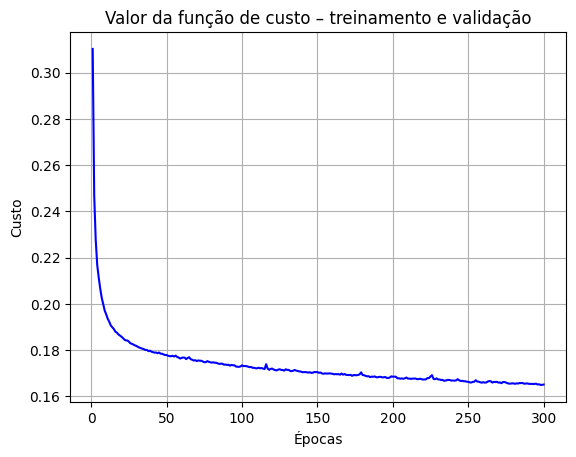

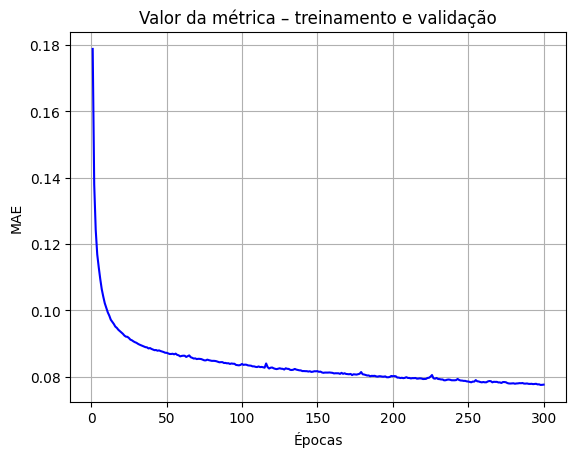

In [ ]:
def plot_train(history):
    history_dict = history.history

    # Salva custos, métricas em vetores
    custo = history_dict['loss']
    acc = history_dict['mae']

    # Cria vetor de épocas
    epocas = range(1, len(custo) + 1)

    # Gráfico dos valores de custo
    plt.plot(epocas, custo, 'b', label='Custo - treinamento')
    plt.title('Valor da função de custo – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Custo')
    plt.grid()
    plt.show()

    # Gráfico dos valores da métrica
    plt.plot(epocas, acc, 'b', label='exatidao- treinamento')
    plt.title('Valor da métrica – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('MAE')
    plt.grid()
    plt.show()

plot_train(results)

### 4.9 Avaliação do autoencoder

Para avaliar o desempenho do autoencoder vamos calcular a função de custo e a métrica.

In [ ]:
# Calcula função de custo e métrica
AEV.evaluate(x_train_flat, x_train_flat)

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1652 - mae: 0.0777


[0.16520936787128448, 0.0776505172252655]

- Observa-se que o erro absoluto médio é de cerca de 0.08, que é um valor  alto para essa aplicação.

Esse resultado tem que ser analisado tendo em mente que adicionamos ruído gaussiano com desvio padrão igual a 1 no espaço latente antes de decoficiar as representações latentes. Além disso, a dimensão das representações latentes é um vetor de somente 2 elementos usado para reconstruir as imagens com 784 pixels. Tendo em vista esses fatores, esse resultado pode ser considerado muito bom.

Obviamente que quanto maior a dimensão do espaço latente melhor tende a ser o desepenho do AEV.

É interessante analisar a influência da dimensão do espaço latente e do fator de regularização `beta` nos resultados do AEV.

### 4.10 Comparação das saídas previstas pelo autoencoder com as entradas

Para verificar visualmente o desempenho do autoencoder, vamos reconstruir algumas imagens.

As saídas previstas pelo autoencoder representam como são reconstruídos os dados de entrada a partir da representação latente dos dados de entrada.

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


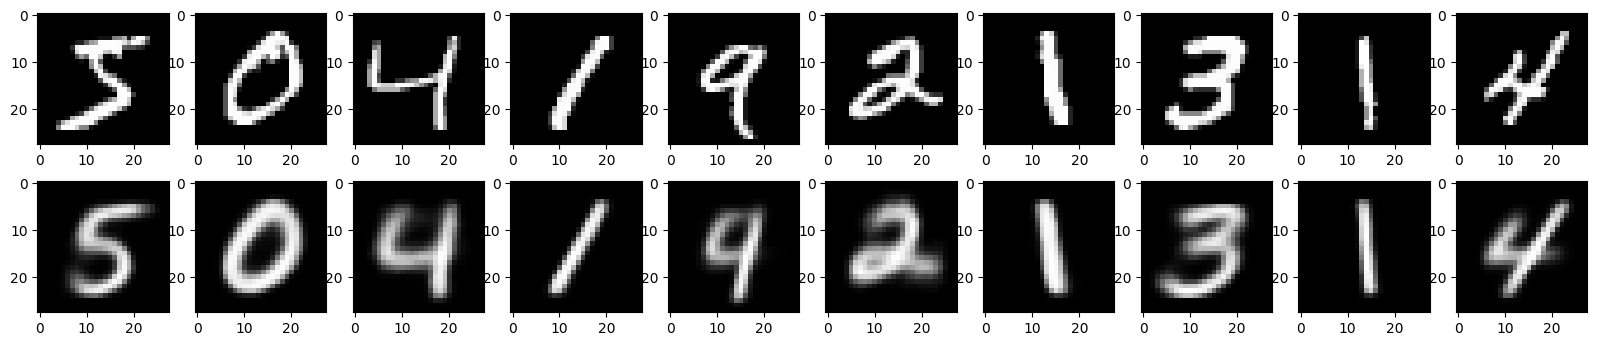

In [ ]:
# Calcula dados reconstriuídos pelo AE
x_prev = 255*AEV.predict(x_train_flat)
x_prev = x_prev.astype(int)

# Mostra imagens originais e reconstruídas
f, pos = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    img_prev = np.reshape(x_prev[i], [28,28])
    pos[0,i].imshow(digits[i], cmap='gray')
    pos[1,i].imshow(img_prev, cmap='gray')
plt.show()

- A primeira linha são as imagens originais e a segunda linha são as imagens reconstruídas.


Observe que as imagens reconstruídas são semelhantes às originais.

### 4.11 Visualização do espaço latente

Observa-se que a visualização gráfica do espaço latente somente é possivel de ser realizada quando as representações latente tem dimensão de no máximo 3 elementos.

O código da célula abaixo está preparado para mostrar somente os dois primeiros elementos das representações latente.

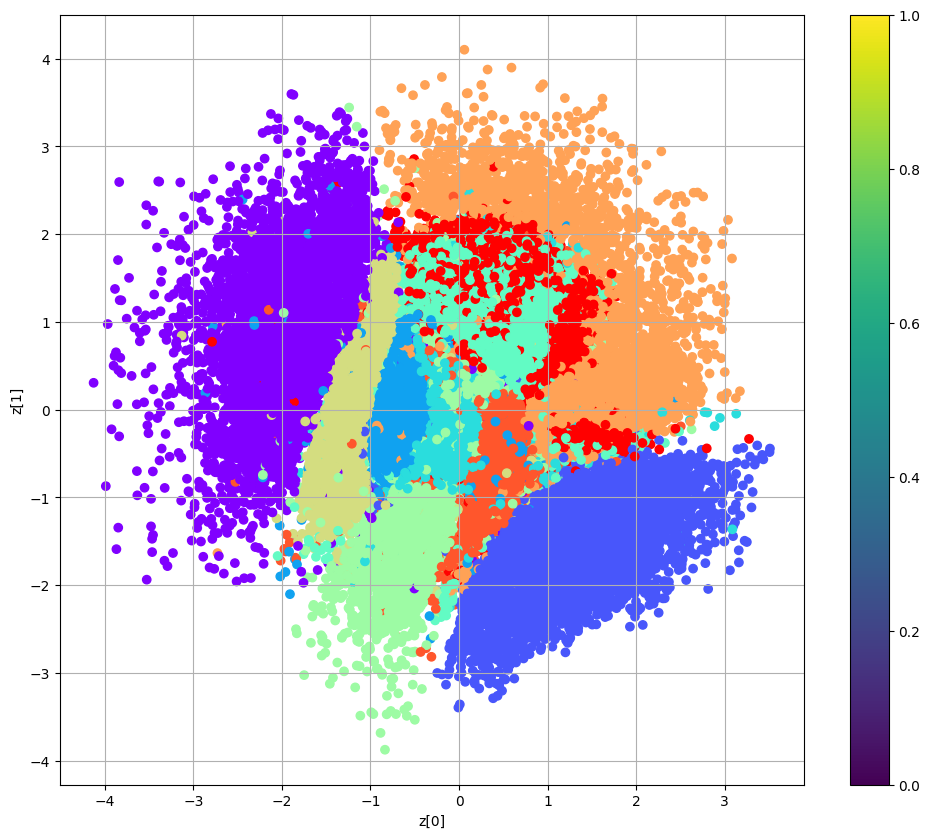

In [ ]:
import matplotlib.cm as cm

# calcula representações latentes
z_mean, log_var, _ = encoder(x_train_flat)

# Define cores para os digitos
colors = cm.rainbow(np.linspace(0, 1, 10))

# Indentica exemplos de cada um dos dígitos e monta gráficos
plt.figure(figsize=(12,10))
plt.scatter(z_mean[:, 0], z_mean[:, 1], c=colors[labels])
plt.colorbar()
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.grid()
plt.show()

Observe que as representações latentes dos dígitos estão centradas na origem do espaço latente e é possível identificar regiões do plano onde se encontram cada um dos dígitos.

Como é impossível visualizar um vetor de vários elementos, alguns dos elementos do vetor latente são visualizados individualmente para verificar se estão próximos de uma distribuição normal padrão.

219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


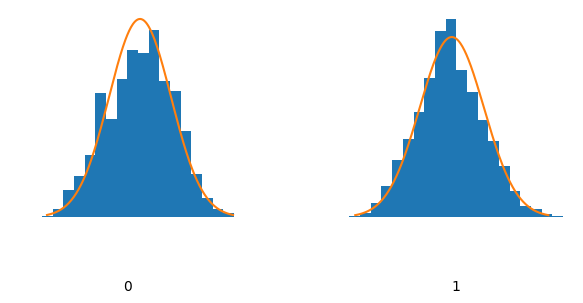

In [ ]:
# Importa função para calcular distribuição normal
from scipy.stats import norm

# Calcula representações latente das imagens
z = encoder.predict(x_train_flat[:7000])[0]

# Cria vetor usado para calcular distribuição normal
x = np.linspace(-3, 3, 300)

# Mostra figuras dos elementos do espaço latente junto com a distribuição normal
fig = plt.figure(figsize=(20, 20))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
nmax = min(latent_dim, 25)
for i in range(nmax):
    ax = fig.add_subplot(5, 5, i+1)
    ax.hist(z[:,i], density=True, bins = 20)
    ax.axis('off')
    ax.text(0.5, -0.35, str(i), fontsize=10, ha='center', transform=ax.transAxes)
    ax.plot(x,norm.pdf(x))

plt.show()

- Observa-se que alguns elementos da representação latente são muito semelhantes a uma distribuição normal padrão. Isso é provocado pela adição do termo de divergência KL.

### 4.12 Geração de novas imagens de dígitos

Para gerar imagens originais de dígitos devemos gerar uma representação latente a partir de um vetor de números aleatórios com distribuição normal com média dentro dos valores dos elementos do espaço latente zero e desvio padrão igual a 1.

Para definir as caracteríticas das representações latentes criadas aleatóriamente, precisamos conhecer as características estatísticas do espaço latente.

In [ ]:
# Cálculo dos parâmetros estatísticos dos elementos do espaço latente calculados anteriormente para 7000 imagens
print('Média:', np.mean(z_mean))
print('Desvio padrão:', np.std(z_mean))
print('Valor máximo', np.max(z_mean))
print('Valor mínimo', np.min(z_mean))

Média: 0.00017959028
Desvio padrão: 1.050078
Valor máximo 4.1021905
Valor mínimo -4.1251583


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step


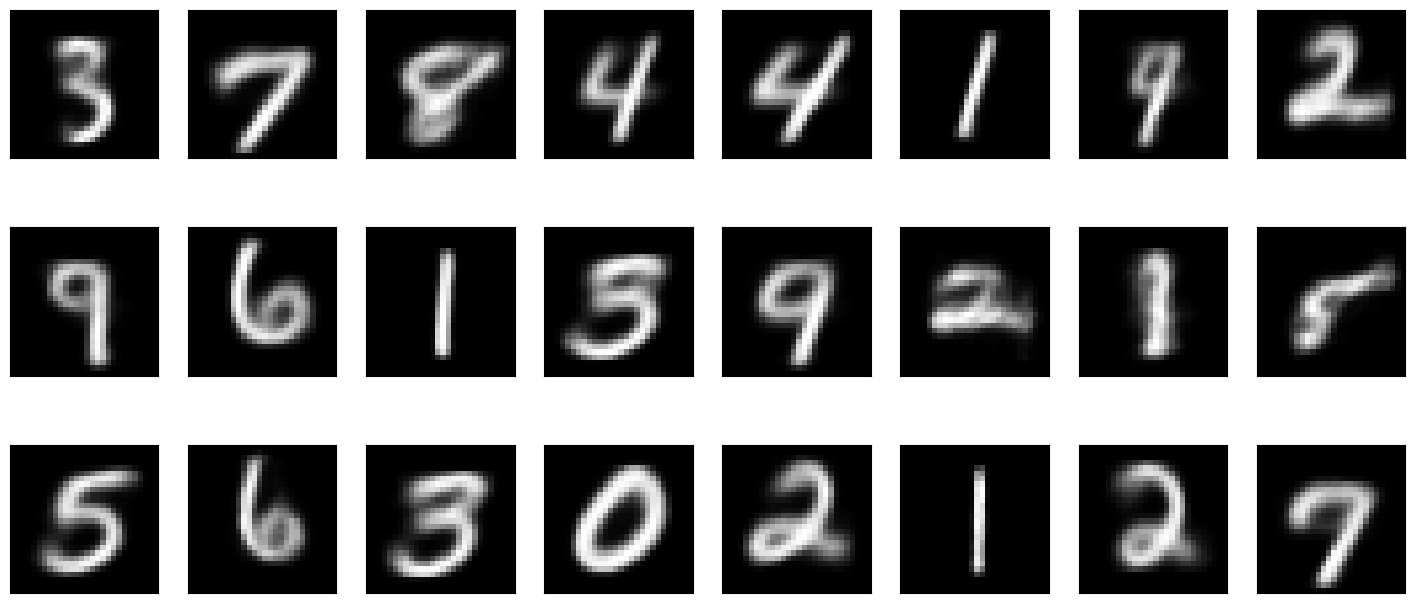

In [ ]:
# representações latente geradas aleatóriamente
# Alterar sacle para selecionar dígitos diferentes
scale = 0.0
z_rand = np.random.randn(24,latent_dim) + 2.0*scale*(np.random.randint(0, 1, (24, latent_dim)) - 0.5)

# Cria imagem a partir da representação latente
reconst_images_vec = decoder.predict(z_rand)

# Redimensiona imagens
reconst_images = np.reshape(reconst_images_vec, (24, 28, 28))

# Mostra imagens construídas
f, pos = plt.subplots(3, 8, figsize=(18, 8))
for i in range(3):
    for j in range(8):
        index = i*8 + j
        pos[i,j].imshow(np.squeeze(reconst_images[index]), cmap='gray')
        pos[i,j].axes.xaxis.set_visible(False)
        pos[i,j].axes.yaxis.set_visible(False)
plt.show()

- Note que as representações latentes criadas possuem um valor médio aleatório dentro do intervalo dos valores máximo e mínimo do espaço latente.

- Observa-se que o AEV é evidentemente capaz de produzir novos dígitos apartir de representações latentes amostrados de uma distribuição normal padrão. O fato de uma rede neural ser capaz de gerar novas dígitos a partir de ruídos aleatórios mostra como ela é poderosa na execução de mapeamentos extremamente complexos!

### 4.13 Grade de dígitos

Vamos criar uma grade onde cada elemento dessa malha mostra um dígito.

As coordenadas x e y dessa grade representam os dois elementos das representaçoes letentes dos dígitos. Assim, em cada posição da grade é mostrado um dígito, ou uma imagem que consiste na mistura de vários dígitos

Vamos usar uma grade que varia de `-scale` a `+scale`, que representa o espaço latente da figura anterior.

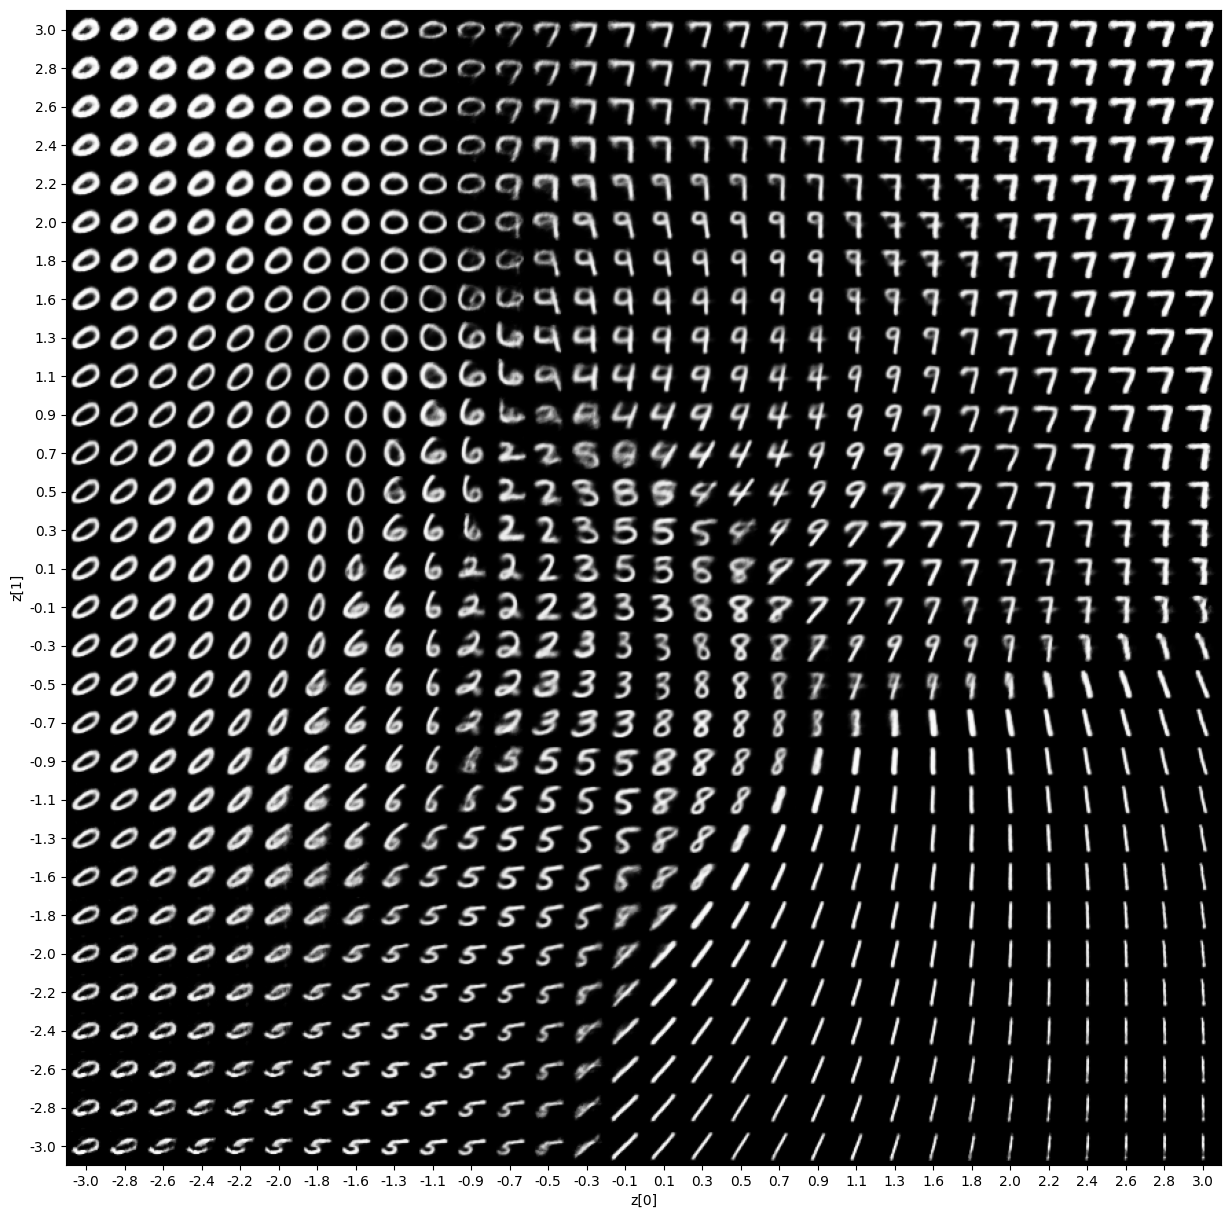

In [ ]:
# Define função para reconstruir dígitos usando o AEV usando um espaço latente bidimensional
def plot_latent_space(decoder, n=30, figsize=15):
    # Largura das imagens
    digit_size = 28

    # Define largura do espaço latente
    scale = 3.0

    # Coordenadas espaçadas linearmente correspondendo ao gráfico 2D das classes de digitos no espaço latente
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    # Monta matriz de dígitos
    figure = np.zeros((digit_size * n, digit_size * n))
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            # Defien coordenadas do espaço latente
            z_sample = np.array([[xi, yi]])

            # Reconstrução da imagem a partir do espaço latente
            x_decoded = decoder.predict(z_sample,verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(decoder)

- Pode-se observar que cada posição da grade e, portanto, do espaço latente representa um dígito.


- Pode-se notar que em algumas posições da grade são mostradas misturas de 2 ou mais dígitos.